# PREPARACION DE LOS DATOS

In [ ]:
from google.colab import files
import pandas as pd

In [ ]:
subir = files.upload()

Saving TelecomX_Limpio.csv to TelecomX_Limpio.csv


In [ ]:
df = pd.read_csv('TelecomX_Limpio.csv')

In [ ]:
df.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total,Cuentas_Diarias
0,0002-ORFBO,0,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.186667
1,0003-MKNFE,0,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,1,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,1,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,1,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.796667


In [ ]:
df = df.drop(columns=['customerID'])

print("Columna 'customerID' eliminada correctamente.")

Columna 'customerID' eliminada correctamente.


In [ ]:
print(f"El dataframe ahora tiene {df.shape[1]} columnas y {df.shape[0]} filas")

El dataframe ahora tiene 21 columnas y 7043 filas


In [ ]:
print("Columnas de texto que necesitan encoding:")
print(df.select_dtypes(include='object').columns.tolist())

Columnas de texto que necesitan encoding:
['customer.gender', 'customer.Partner', 'customer.Dependents', 'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService', 'internet.OnlineSecurity', 'internet.OnlineBackup', 'internet.DeviceProtection', 'internet.TechSupport', 'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract', 'account.PaperlessBilling', 'account.PaymentMethod']


In [ ]:
df = pd.get_dummies(df, drop_first=True)

print(f"Ahora el dataframe tiene {df.shape[1]} columnas")
df.head()

Ahora el dataframe tiene 32 columnas


,Churn,customer.SeniorCitizen,customer.tenure,account.Charges.Monthly,account.Charges.Total,Cuentas_Diarias,customer.gender_Male,customer.Partner_Yes,customer.Dependents_Yes,phone.PhoneService_Yes,...,internet.StreamingTV_No internet service,internet.StreamingTV_Yes,internet.StreamingMovies_No internet service,internet.StreamingMovies_Yes,account.Contract_One year,account.Contract_Two year,account.PaperlessBilling_Yes,account.PaymentMethod_Credit card (automatic),account.PaymentMethod_Electronic check,account.PaymentMethod_Mailed check
0,0,0,9,65.6,593.30,2.186667,False,True,True,True,...,False,True,False,False,True,False,True,False,False,True
1,0,0,9,59.9,542.40,1.996667,True,False,False,True,...,False,False,False,True,False,False,False,False,False,True
2,1,0,4,73.9,280.85,2.463333,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
3,1,1,13,98.0,1237.85,3.266667,True,True,False,True,...,False,True,False,True,False,False,True,False,True,False
4,1,1,3,83.9,267.40,2.796667,False,True,False,True,...,False,True,False,False,False,False,True,False,False,True


In [ ]:
churn_counts = df['Churn'].value_counts()
churn_percent = df['Churn'].value_counts(normalize=True) * 100

print("Cantidad de clientes por categoria:")
print(churn_counts)
print("\nPorcentaje:")
print(churn_percent.round(2))

Cantidad de clientes por categoria:
Churn
0    5174
1    1869
Name: count, dtype: int64

Porcentaje:
Churn
0    73.46
1    26.54
Name: proportion, dtype: float64


In [ ]:
y = df['Churn']
X = df.drop(columns=['Churn'])

print("Separación variables")
print(f"X tiene {X.shape[1]} columnas y {X.shape[0]} filas")
print(f"y tiene {y.shape[0]} valores")

Separación variables
X tiene 31 columnas y 7043 filas
y tiene 7043 valores


In [ ]:
from sklearn.preprocessing import StandardScaler


In [ ]:
scaler = StandardScaler()


X_scaled = scaler.fit_transform(X)


X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("Normalización aplicada")
print("Datos normalizados:")
X_scaled.head()

Normalización aplicada
Datos normalizados:


,customer.SeniorCitizen,customer.tenure,account.Charges.Monthly,account.Charges.Total,Cuentas_Diarias,customer.gender_Male,customer.Partner_Yes,customer.Dependents_Yes,phone.PhoneService_Yes,phone.MultipleLines_No phone service,...,internet.StreamingTV_No internet service,internet.StreamingTV_Yes,internet.StreamingMovies_No internet service,internet.StreamingMovies_Yes,account.Contract_One year,account.Contract_Two year,account.PaperlessBilling_Yes,account.PaymentMethod_Credit card (automatic),account.PaymentMethod_Electronic check,account.PaymentMethod_Mailed check
0,-0.439916,-0.951682,0.027862,-0.745490,0.027862,-1.009559,1.034530,1.529024,0.327438,-0.327438,...,-0.525927,1.265612,-0.525927,-0.796070,1.944582,-0.562975,0.829798,-0.525047,-0.711026,1.835513
1,-0.439916,-0.951682,-0.161583,-0.767961,-0.161583,0.990532,-0.966622,-0.654012,0.327438,-0.327438,...,-0.525927,-0.790132,-0.525927,1.256171,-0.514249,-0.562975,-1.205113,-0.525047,-0.711026,1.835513
2,-0.439916,-1.155283,0.303720,-0.883431,0.303720,0.990532,-0.966622,-0.654012,0.327438,-0.327438,...,-0.525927,-0.790132,-0.525927,-0.796070,-0.514249,-0.562975,0.829798,-0.525047,1.406418,-0.544807
3,2.273159,-0.788800,1.104706,-0.460934,1.104706,0.990532,1.034530,-0.654012,0.327438,-0.327438,...,-0.525927,1.265612,-0.525927,1.256171,-0.514249,-0.562975,0.829798,-0.525047,1.406418,-0.544807
4,2.273159,-1.196004,0.636080,-0.889368,0.636080,-1.009559,1.034530,-0.654012,0.327438,-0.327438,...,-0.525927,1.265612,-0.525927,-0.796070,-0.514249,-0.562975,0.829798,-0.525047,-0.711026,1.835513


# CORRELACION Y SELECCION DE VARIABLES

In [ ]:
df_corr = X_scaled.copy()
df_corr['Churn'] = y.values

correlation_with_churn = df_corr.corr()['Churn'].drop('Churn').sort_values(ascending=False)

print("Variables más correlacionadas con Churn")
print(correlation_with_churn)

Variables más correlacionadas con Churn
internet.InternetService_Fiber optic             0.308020
account.PaymentMethod_Electronic check           0.301919
Cuentas_Diarias                                  0.193356
account.Charges.Monthly                          0.193356
account.PaperlessBilling_Yes                     0.191825
customer.SeniorCitizen                           0.150889
internet.StreamingTV_Yes                         0.063228
internet.StreamingMovies_Yes                     0.061382
phone.MultipleLines_Yes                          0.040102
phone.PhoneService_Yes                           0.011942
customer.gender_Male                            -0.008612
phone.MultipleLines_No phone service            -0.011942
internet.DeviceProtection_Yes                   -0.066160
internet.OnlineBackup_Yes                       -0.082255
account.PaymentMethod_Mailed check              -0.091683
account.PaymentMethod_Credit card (automatic)   -0.134302
customer.Partner_Yes            

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns



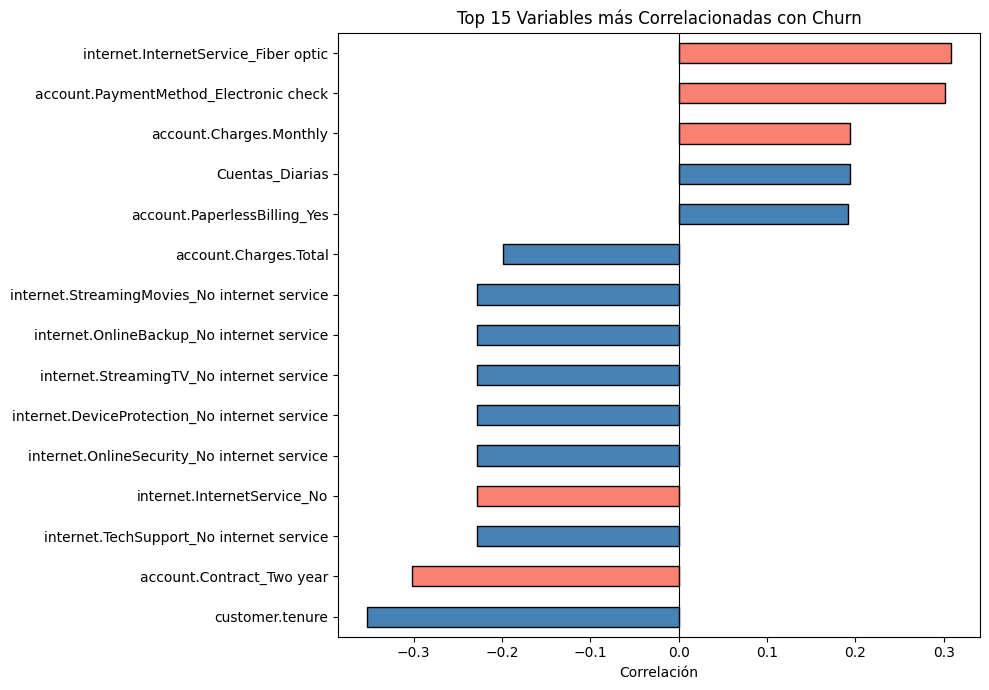

In [ ]:
top_15 = correlation_with_churn.abs().sort_values(ascending=False).head(15)
top_15_values = correlation_with_churn[top_15.index]

plt.figure(figsize=(10, 7))
colors = ['salmon' if v > 0 else 'steelblue' for v in top_15_values]
top_15_values.sort_values().plot(kind='barh', color=colors, edgecolor='black')
plt.title('Top 15 Variables más Correlacionadas con Churn')
plt.xlabel('Correlación')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()



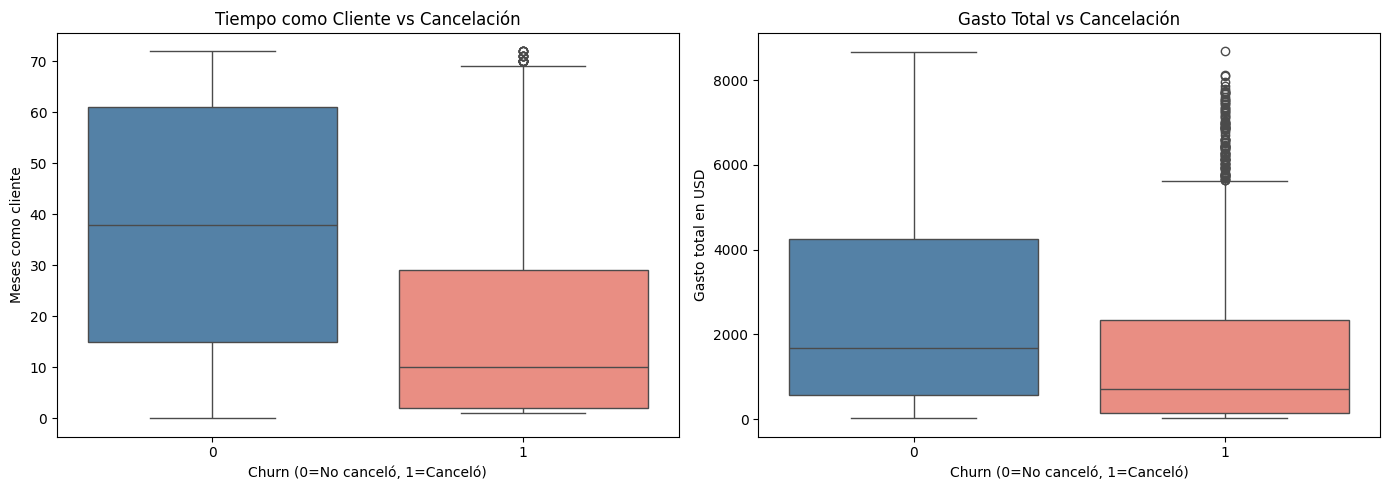

In [ ]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x=y, y=df['customer.tenure'], ax=axes[0],
            palette={'0': 'steelblue', '1': 'salmon'})
axes[0].set_title('Tiempo como Cliente vs Cancelación')
axes[0].set_xlabel('Churn (0=No canceló, 1=Canceló)')
axes[0].set_ylabel('Meses como cliente')

sns.boxplot(x=y, y=df['account.Charges.Total'], ax=axes[1],
            palette={'0': 'steelblue', '1': 'salmon'})
axes[1].set_title('Gasto Total vs Cancelación')
axes[1].set_xlabel('Churn (0=No canceló, 1=Canceló)')
axes[1].set_ylabel('Gasto total en USD')

plt.tight_layout()
plt.show()

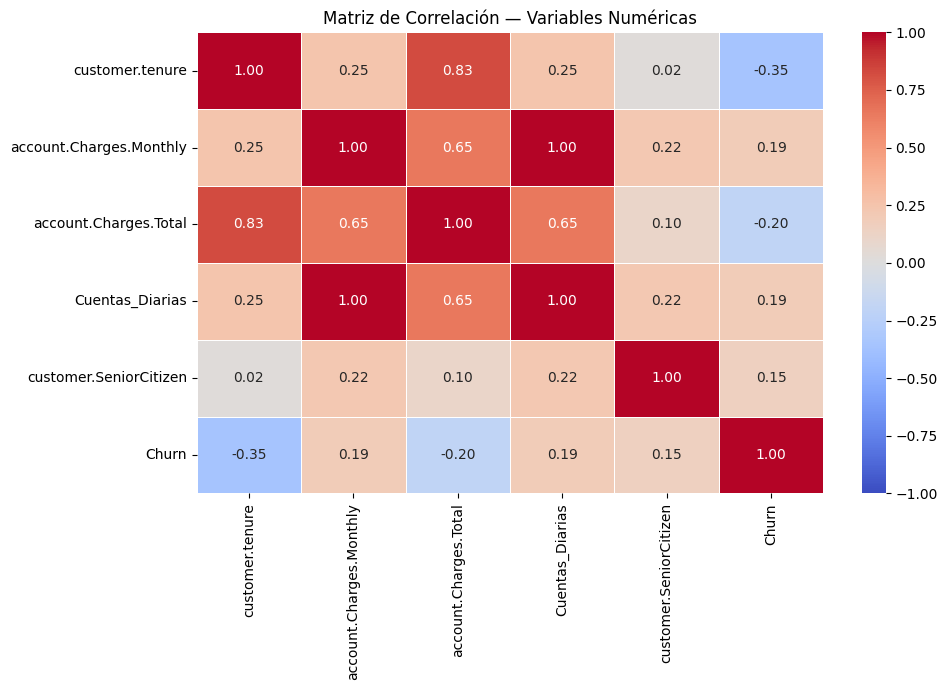

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


df_corr = X_scaled.copy()
df_corr['Churn'] = y.values


vars_importantes = ['customer.tenure', 'account.Charges.Monthly',
                    'account.Charges.Total', 'Cuentas_Diarias',
                    'customer.SeniorCitizen', 'Churn']


plt.figure(figsize=(10, 7))
sns.heatmap(
    df_corr[vars_importantes].corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5,
    vmin=-1, vmax=1
)
plt.title('Matriz de Correlación — Variables Numéricas')
plt.tight_layout()
plt.show()

# MODELADO PREDICTIVO

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print("Datos divididos")
print(f"Entrenamiento: {X_train.shape[0]} filas")
print(f"Prueba:        {X_test.shape[0]} filas")

Datos divididos
Entrenamiento: 5634 filas
Prueba:        1409 filas


In [ ]:
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)
y_pred_knn = knn_model.predict(X_test)

print("Modelo KNN entrenado")



Modelo KNN entrenado


In [ ]:
from sklearn.linear_model import LogisticRegression


Exactitud:  80.62%
Precisión: 66.67%
Recall:    53.62%
F1-Score:  59.44%


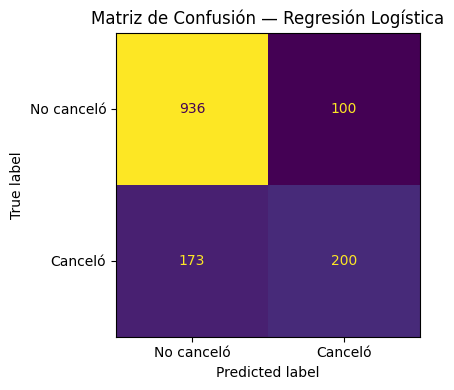

In [ ]:
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay)

log_model = LogisticRegression(random_state=42)
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)



print(f"Exactitud:  {accuracy_score(y_test, y_pred_log):.2%}")
print(f"Precisión: {precision_score(y_test, y_pred_log):.2%}")
print(f"Recall:    {recall_score(y_test, y_pred_log):.2%}")
print(f"F1-Score:  {f1_score(y_test, y_pred_log):.2%}")


import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(5,4))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_log),
                       display_labels=['No canceló','Canceló']).plot(ax=ax, colorbar=False)
plt.title('Matriz de Confusión — Regresión Logística')
plt.tight_layout()
plt.show()

Resultados
Exactitud  75.73%
Precisión  54.44%
Recall:    50.94%
F1-Score:  52.63%


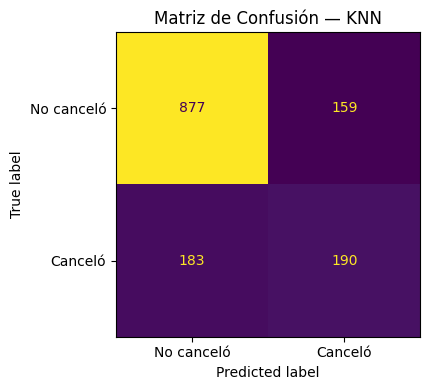

In [ ]:
print("Resultados")

print(f"Exactitud  {accuracy_score(y_test, y_pred_knn):.2%}")
print(f"Precisión  {precision_score(y_test, y_pred_knn):.2%}")
print(f"Recall:    {recall_score(y_test, y_pred_knn):.2%}")
print(f"F1-Score:  {f1_score(y_test, y_pred_knn):.2%}")

# Matriz de confusión
fig, ax = plt.subplots(figsize=(5,4))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_knn),
                       display_labels=['No canceló','Canceló']).plot(ax=ax, colorbar=False)
plt.title('Matriz de Confusión — KNN')
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

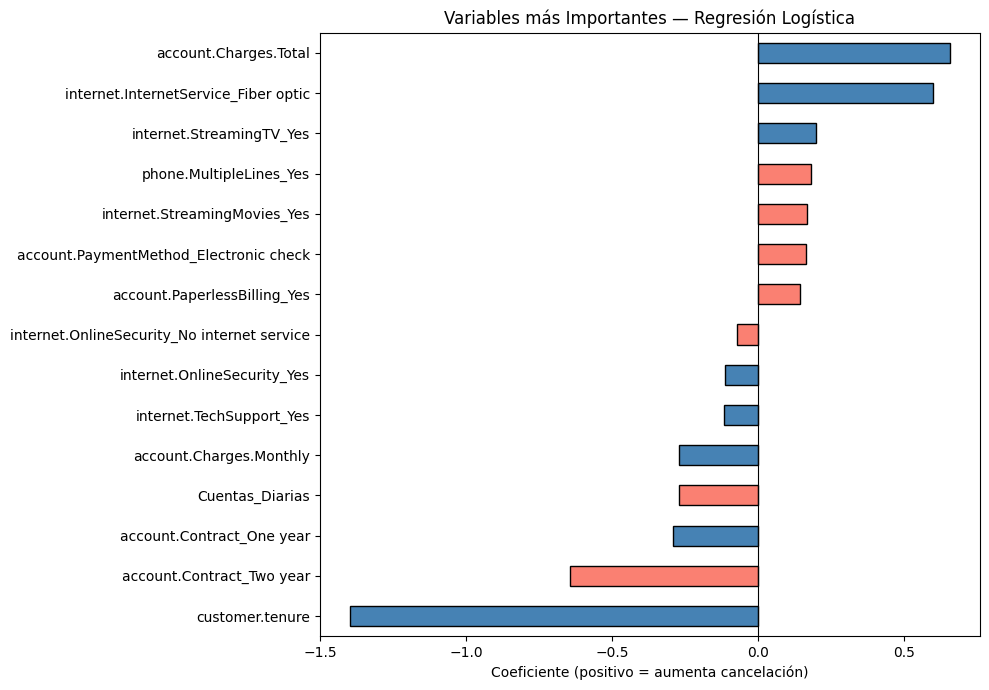

In [ ]:


coeficientes = pd.Series(
    log_model.coef_[0],
    index=X_scaled.columns
)

top_coef = coeficientes.abs().sort_values(ascending=False).head(15)
top_coef_values = coeficientes[top_coef.index]

plt.figure(figsize=(10, 7))
colors = ['salmon' if v > 0 else 'steelblue' for v in top_coef_values]
top_coef_values.sort_values().plot(kind='barh', color=colors, edgecolor='black')
plt.title('Variables más Importantes — Regresión Logística')
plt.xlabel('Coeficiente (positivo = aumenta cancelación)')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()



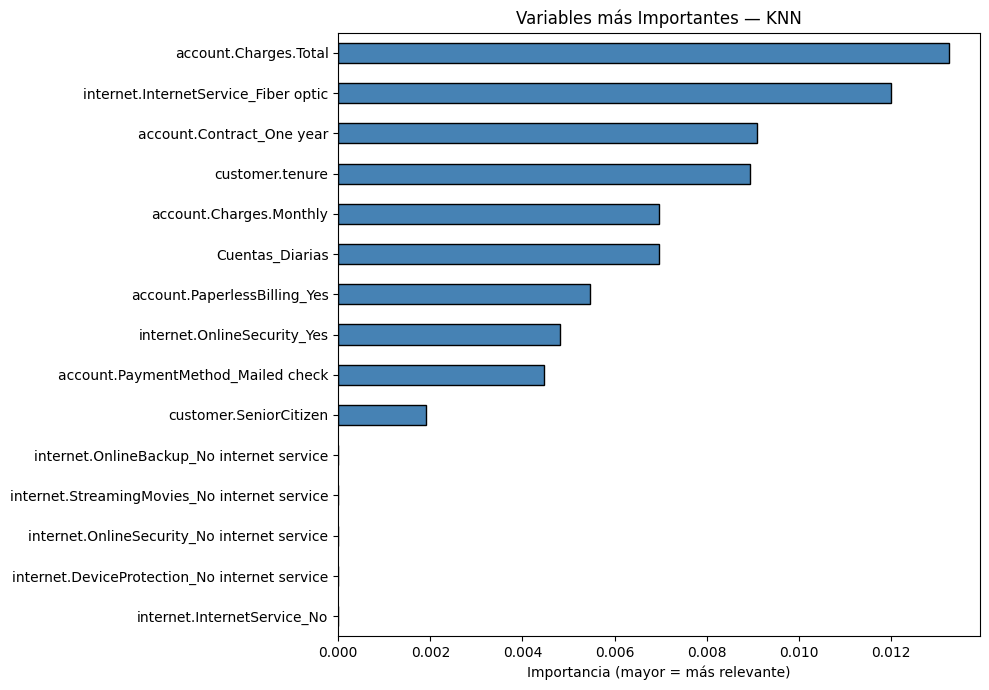

In [31]:

from sklearn.inspection import permutation_importance


result = permutation_importance(
    knn_model, X_test, y_test,
    n_repeats=10,
    random_state=42
)


knn_importance = pd.Series(
    result.importances_mean,
    index=X_scaled.columns
).sort_values(ascending=False).head(15)


plt.figure(figsize=(10, 7))
knn_importance.sort_values().plot(
    kind='barh', color='steelblue', edgecolor='black'
)
plt.title('Variables más Importantes — KNN')
plt.xlabel('Importancia (mayor = más relevante)')
plt.tight_layout()
plt.show()

In [32]:
from sklearn.tree import DecisionTreeClassifier

X_train_orig, X_test_orig, y_train_orig, y_test_orig = train_test_split(
    X, y, test_size=0.2, random_state=42
)

tree_model = DecisionTreeClassifier(max_depth=5, random_state=42)
tree_model.fit(X_train_orig, y_train_orig)

y_pred_tree = tree_model.predict(X_test_orig)



ÁRBOL DE DECISIÓN
Exactitud  (Accuracy):  79.13%
Precisión  (Precision): 65.99%
Recall:                 43.70%
F1-Score:               52.58%


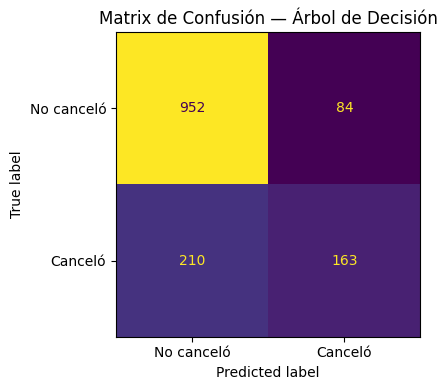

In [34]:

print("ÁRBOL DE DECISIÓN")
print(f"Exactitud  (Accuracy):  {accuracy_score(y_test_orig, y_pred_tree):.2%}")
print(f"Precisión  (Precision): {precision_score(y_test_orig, y_pred_tree):.2%}")
print(f"Recall:                 {recall_score(y_test_orig, y_pred_tree):.2%}")
print(f"F1-Score:               {f1_score(y_test_orig, y_pred_tree):.2%}")

# Matrix de confusión
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(5,4))
ConfusionMatrixDisplay(confusion_matrix(y_test_orig, y_pred_tree),
                       display_labels=['No canceló','Canceló']).plot(ax=ax, colorbar=False)
plt.title('Matrix de Confusión  Árbol de Decisión')
plt.tight_layout()
plt.show()

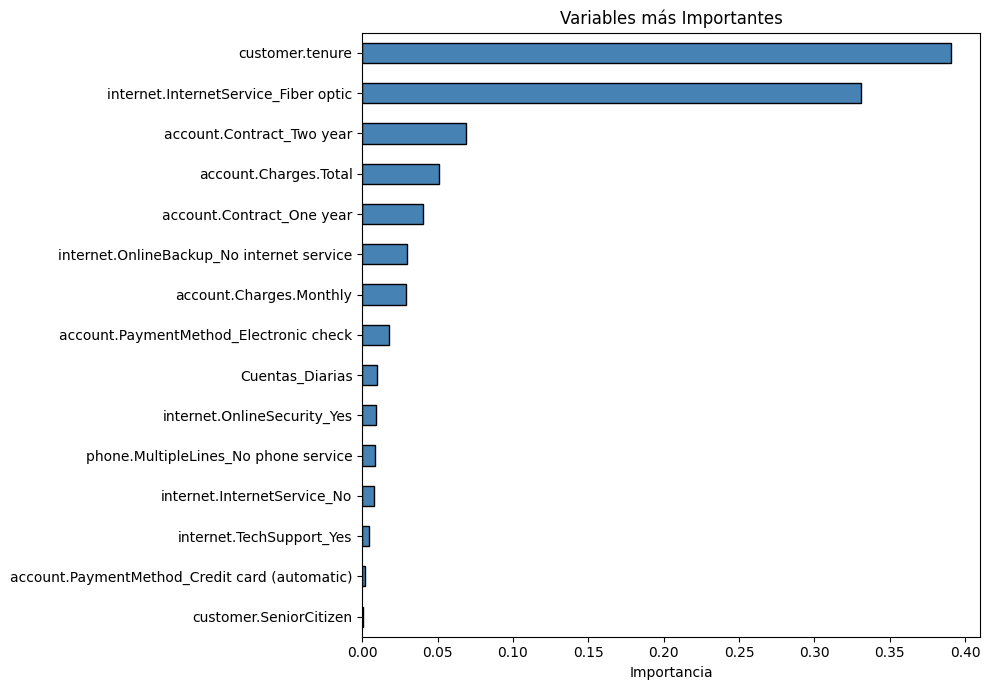

In [35]:
import pandas as pd

tree_importance = pd.Series(
    tree_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 7))
tree_importance.sort_values().plot(
    kind='barh', color='steelblue', edgecolor='black'
)
plt.title('Variables más Importantes')
plt.xlabel('Importancia')
plt.tight_layout()
plt.show()

# **Conclusión**

¡Hola! Soy estudiante de ciencias de datos en el programa Oracle Next One x Alura y este es mi primer proyecto completo de Machine Learning. La verdad estoy súper emocionada de haber llegado hasta aquí porque al principio todo se veía muy complicado, pero paso a paso fue tomando sentido. En este informe voy a contarles qué encontré, qué modelos usé y qué le recomendaría a Telecom X para retener a sus clientes. ¡Espero que les guste!

# ¿Qué modelos usé y por qué?
Entrené tres modelos de clasificación, combinando modelos que requieren normalización con uno que no la necesita:
1. Regresión Logística — Lo elegí porque es uno de los modelos más usados para predecir si algo va a pasar o no. Es muy interpretable, lo que me permite entender exactamente qué variables están empujando a un cliente a cancelar. Requiere normalización porque trabaja con coeficientes que se ven afectados por la escala de los datos.
2. KNN (K-Nearest Neighbors) — La idea de buscar los 5 clientes más parecidos y ver qué hicieron ellos me pareció muy intuitiva. También requiere normalización porque calcula distancias entre puntos — si una variable tiene números muy grandes, dominaría sobre las demás sin normalizar.
3. Árbol de Decisión — Este modelo toma decisiones tipo "¿el cliente lleva más de 12 meses? Si sí, es menos probable que cancele". No necesita normalización porque solo compara valores entre sí, sin importar su escala. Lo incluí para complementar el análisis con un enfoque diferente.


# Resultados de los Modelos

 La Regresión Logística fue el mejor modelo en todas las métricas. Predijo correctamente el 80.62% de los casos y tuvo la mejor capacidad para detectar clientes que cancelarían.
El Recall de todos los modelos no es muy alto, lo que significa que todavía se nos escapan algunos clientes en riesgo. Esto se podría mejorar con técnicas de balanceo de clases como SMOTE o ajustando los umbrales de decisión.
No observé señales graves de overfitting ni underfitting en ningún modelo — aprendieron bien sin memorizar los datos.

 ¿Qué factores influyen más en la cancelación?
Lo más emocionante de este proyecto fue que los 3 modelos coincidieron en las mismas variables importantes. Eso me da mucha confianza de que estos factores son reales y no casualidades.
1.  Tiempo como cliente (tenure) El más importante
Los clientes nuevos tienen altísimo riesgo de cancelar. La empresa tiene un problema crítico en los primeros meses  si no logran fidelizar al cliente desde el inicio, lo pierden rápido.
2. Internet de Fibra Óptica
Los clientes con fibra óptica cancelan más. Mi hipótesis es que tienen expectativas muy altas de velocidad y calidad, y si el servicio no las cumple, se van sin pensarlo dos veces.
3. Tipo de contrato
Los clientes con contrato mensual cancelan muchísimo más que los de contrato anual o de dos años. Sin compromiso, es muy fácil cancelar cuando algo no gusta.
4. Método de pago: cheque electrónico
Los clientes que pagan con cheque electrónico cancelan más. Puede reflejar menor compromiso o problemas recurrentes con los pagos.
5. Cargos mensuales altos
A mayor costo mensual, mayor probabilidad de cancelación. El precio es un factor decisivo.


# Mis Recomendaciones para Telecom X
 1. Programa de bienvenida para clientes nuevos
Los primeros meses son críticos. Recomiendo crear un onboarding especial — llamadas de seguimiento, descuentos iniciales y soporte dedicado para hacer sentir al cliente valorado desde el día uno.
 2. Incentivar contratos anuales
Ofrecer beneficios atractivos a quienes firmen contratos largos descuentos, meses gratis o servicios adicionales. Esto reduce la facilidad de cancelar impulsivamente.
 3. Mejorar la experiencia de Fibra Óptica
Investigar por qué estos clientes cancelan más ¿es el precio? ¿La velocidad real vs prometida? Encuestas de satisfacción específicas para este segmento serían muy útiles.
 4. Promover pagos automáticos
Incentivar el cambio de cheque electrónico a débito automático o tarjeta. Esto reduce cancelaciones y retrasos en pagos.
 5. Ofrecer seguridad online y soporte técnico
El análisis mostró que tener OnlineSecurity y TechSupport reduce la cancelación. Telecom X podría ofrecerlos como prueba gratuita para aumentar fidelización.

# Reflexión Final
Este proyecto fue todo un reto para mí porque nunca había construido un pipeline de Machine Learning completo. Hubo momentos en que me trabé con errores de código o no entendía por qué los números salían así, pero cada obstáculo que superé me enseñó algo nuevo.
Lo que más me llevo es que los datos sí cuentan historias reales detrás de cada número hay un cliente con una razón para quedarse o irse. Y el trabajo de una científica de datos es escuchar esa historia y traducirla en acciones concretas para la empresa.
¡Gracias por leer hasta aquí! Sé que todavía me falta mucho por aprender, pero estoy muy orgullosa de este primer paso.
